In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os
os.listdir("/content/drive/MyDrive/Data Visualization Project")

['national_M2024_dl.xlsx',
 'Copy of OEWS - Employment and Wage Dataset - 2024 OEWS data.csv',
 'national_M2024_dl.csv',
 'Final Presentation.gdoc',
 'Copy of Data Visualization(Project).ipynb',
 'Data Visualization(Project).ipynb',
 'Project Final Tableau Plots.twb',
 'Final data viz_ R.R',
 'Final_Presentation_Data_Visualization.pptx',
 'Final Data Visualization(Project).ipynb']

In [11]:
#load raw data
df = pd.read_csv("/content/drive/MyDrive/Data Visualization Project/national_M2024_dl.csv")
df.head()


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,23.80,37.89,60.44,"29,990","36,730","49,500","78,810","125,720",NaN,NaN
1,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,58.70,82.50,#,"57,010","79,900","122,090","171,610",#,NaN,NaN
2,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,50.48,81.01,#,"47,510","68,800","104,990","168,490",#,NaN,NaN
3,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,99.24,#,#,"73,710","126,080","206,420",#,#,NaN,NaN
4,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,99.24,#,#,"73,710","126,080","206,420",#,#,NaN,NaN


In [12]:
df.dtypes

,0
AREA,int64
AREA_TITLE,object
AREA_TYPE,int64
PRIM_STATE,object
NAICS,int64
NAICS_TITLE,object
I_GROUP,object
OWN_CODE,int64
OCC_CODE,object
OCC_TITLE,object


In [13]:
#this removes hidden spaces
df.columns = df.columns.str.strip()


In [14]:

#filter us only
df = df[df["AREA_TITLE"] == "U.S."]


In [15]:
#Select Needed Columns
df = df[["OCC_TITLE", "O_GROUP", "TOT_EMP", "H_MEAN", "A_MEAN"]]


In [16]:
#rename columns
df = df.rename(columns={
    "OCC_TITLE": "occupation",
    "O_GROUP": "soc_group",
    "TOT_EMP": "employment",
    "H_MEAN": "hourly_mean",
    "A_MEAN": "annual_mean"
})

In [17]:
#Remove Commas & Convert to Numeric
for col in ["employment", "hourly_mean", "annual_mean"]:
    # Remove commas
    df[col] = df[col].astype(str).str.replace(",", "", regex=False)
    # Convert to numeric
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
#Drop Missing Values
df = df.dropna(subset=["employment", "annual_mean","hourly_mean"])

#FIX: remove the “All Occupations” row which distorts graphs
df = df[df["occupation"] != "All Occupations"]
df.head()


,occupation,soc_group,employment,hourly_mean,annual_mean
1,Management Occupations,major,10966830,68.15,141760.0
2,Top Executives,minor,3822780,67.24,139860.0
3,Chief Executives,broad,211850,126.41,262930.0
4,Chief Executives,detailed,211850,126.41,262930.0
5,General and Operations Managers,broad,3584420,64.00,133120.0


In [19]:
print(df.describe())

         employment  hourly_mean    annual_mean
count  1.312000e+03  1312.000000    1312.000000
mean   4.523652e+05    36.101677   75090.617378
std    1.330068e+06    22.084857   45936.466897
min    1.800000e+02    14.820000   30830.000000
25%    2.095500e+04    22.930000   47700.000000
50%    7.301000e+04    30.000000   62390.000000
75%    2.873525e+05    41.267500   85840.000000
max    1.821807e+07   216.740000  450810.000000


In [20]:
#saving clean data
df.to_csv("oews_clean_midterm.csv", index=False)

In [21]:
# from google.colab import files

# files.download("oews_clean_midterm.csv")

In [22]:
df = pd.read_csv("oews_clean_midterm.csv")
print(df.dtypes)
print(df.isna().sum())
print(df.shape)

occupation      object
soc_group       object
employment       int64
hourly_mean    float64
annual_mean    float64
dtype: object
occupation     0
soc_group      0
employment     0
hourly_mean    0
annual_mean    0
dtype: int64
(1312, 5)


Now data is clean

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df.dtypes

,0
occupation,object
soc_group,object
employment,int64
hourly_mean,float64
annual_mean,float64


In [25]:
df[["employment","hourly_mean","annual_mean"]] = df[["employment","hourly_mean","annual_mean"]].apply(pd.to_numeric)


Bar Plot — Top 15 Occupations by Employment

In [26]:
top15 = df.sort_values("employment", ascending=False).head(15)


/tmp/ipykernel_1035/4135663465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="employment", y="occupation", data=top15, palette="viridis")


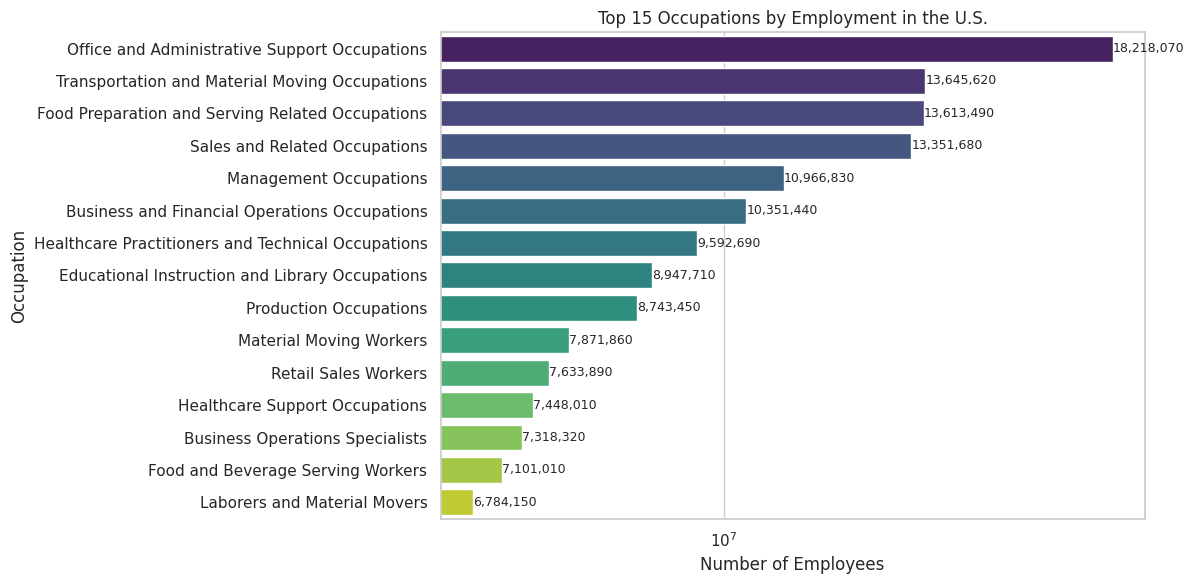

In [27]:
plt.figure(figsize=(12,6))
sns.barplot(x="employment", y="occupation", data=top15, palette="viridis")

plt.xscale("log") # We added log scale to fix the problem where one large value was hiding all others.

plt.title("Top 15 Occupations by Employment in the U.S.")
plt.xlabel("Number of Employees")
plt.ylabel("Occupation")
for i, val in enumerate(top15["employment"]):
    plt.text(val, i, f"{int(val):,}", va='center', ha='left', fontsize=9)
plt.tight_layout()
plt.show()

Box Plot — Wage Distribution by Major Occupational Group

/tmp/ipykernel_1035/1542462727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="soc_group", y="annual_mean", data=df, palette="pastel")


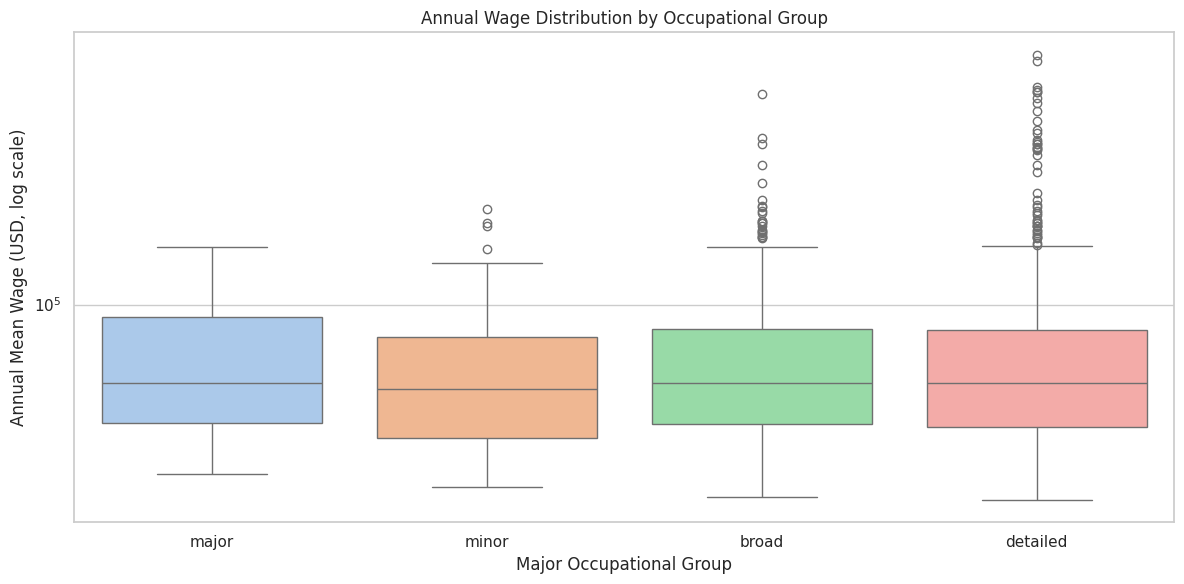

In [28]:
plt.figure(figsize=(12,6))
sns.boxplot(x="soc_group", y="annual_mean", data=df, palette="pastel")
plt.yscale("log")
plt.title("Annual Wage Distribution by Occupational Group")
plt.xlabel("Major Occupational Group")
plt.ylabel("Annual Mean Wage (USD, log scale)")
plt.tight_layout()
plt.show()


Scatter Plot — Employment vs. Average Wage

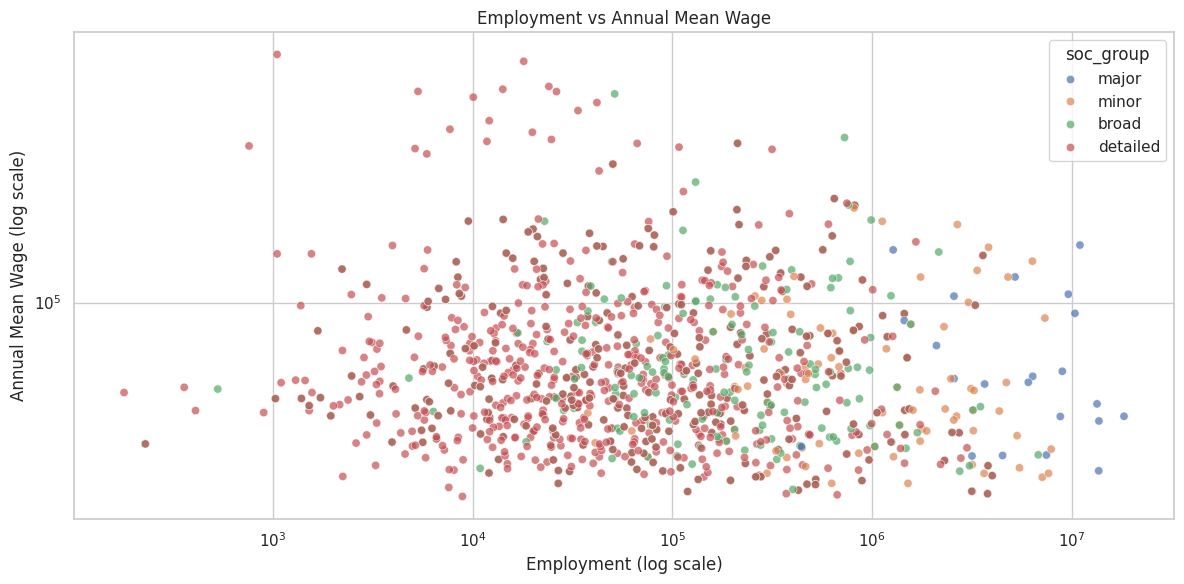

In [29]:
plt.figure(figsize=(12,6))
sns.scatterplot(x="employment", y="annual_mean", hue="soc_group", data=df, alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.title("Employment vs Annual Mean Wage")
plt.xlabel("Employment (log scale)")
plt.ylabel("Annual Mean Wage (log scale)")
plt.tight_layout()
plt.show()


Histogram / Density — National Wage Distribution

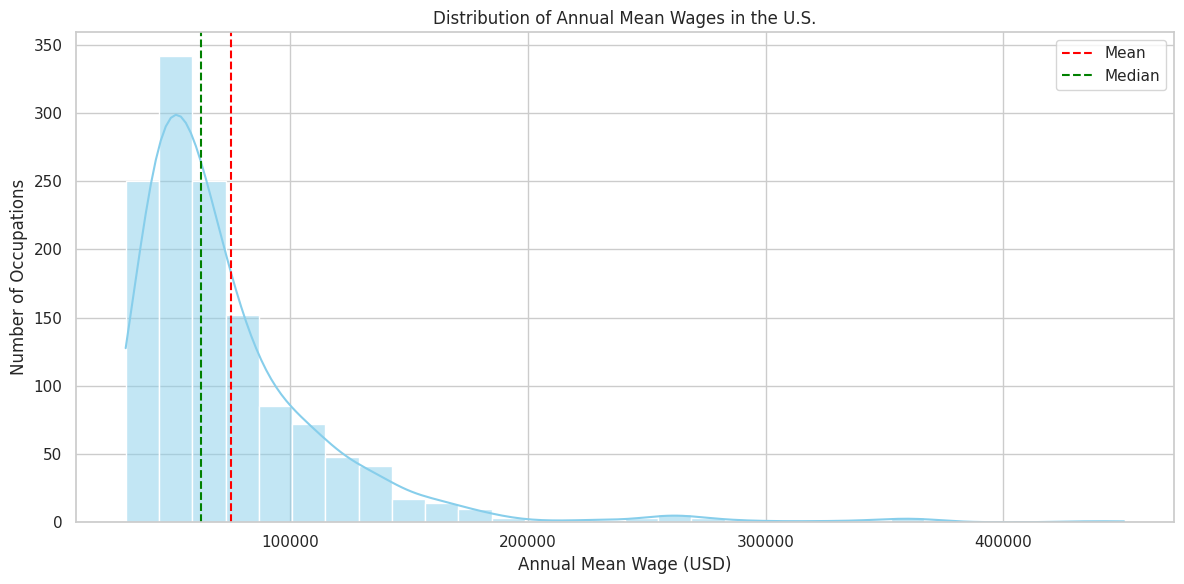

In [30]:
plt.figure(figsize=(12,6))
sns.histplot(df["annual_mean"], bins=30, kde=True, color="skyblue")
plt.axvline(df["annual_mean"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["annual_mean"].median(), color="green", linestyle="--", label="Median")
plt.title("Distribution of Annual Mean Wages in the U.S.")
plt.xlabel("Annual Mean Wage (USD)")
plt.ylabel("Number of Occupations")
plt.legend()
plt.tight_layout()
plt.show()

**Final figure Plot **

Pie Chart — Employment Share by SOC Group
Story

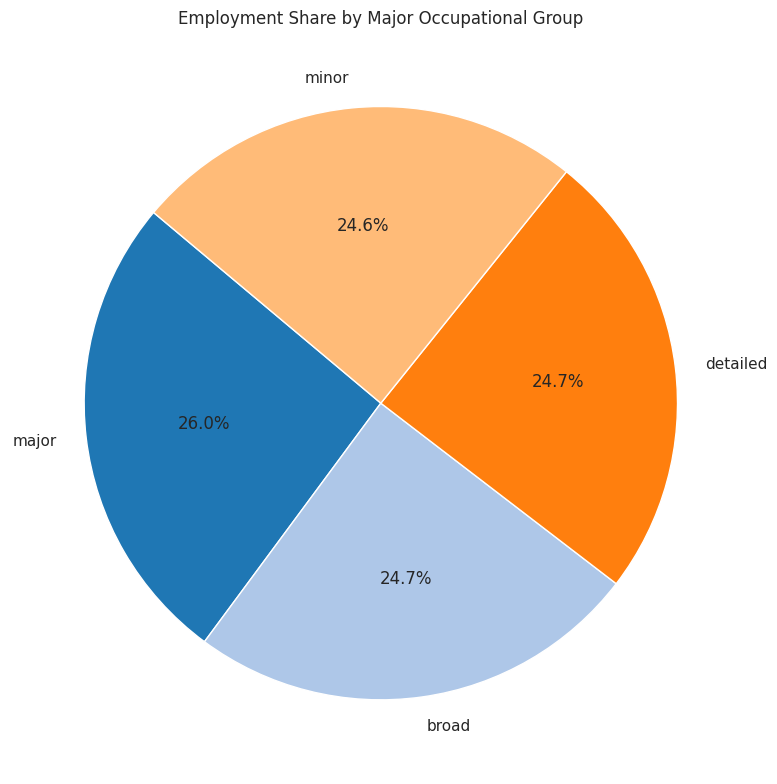

In [31]:
soc_employment = df.groupby("soc_group")["employment"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))
plt.pie(soc_employment, labels=soc_employment.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("tab20"))
plt.title("Employment Share by Major Occupational Group")
plt.tight_layout()
plt.show()

Violin Plot — Hourly Wage Distribution by SOC Group



/tmp/ipykernel_1035/8362944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="soc_group", y="hourly_mean", data=df, palette="pastel")


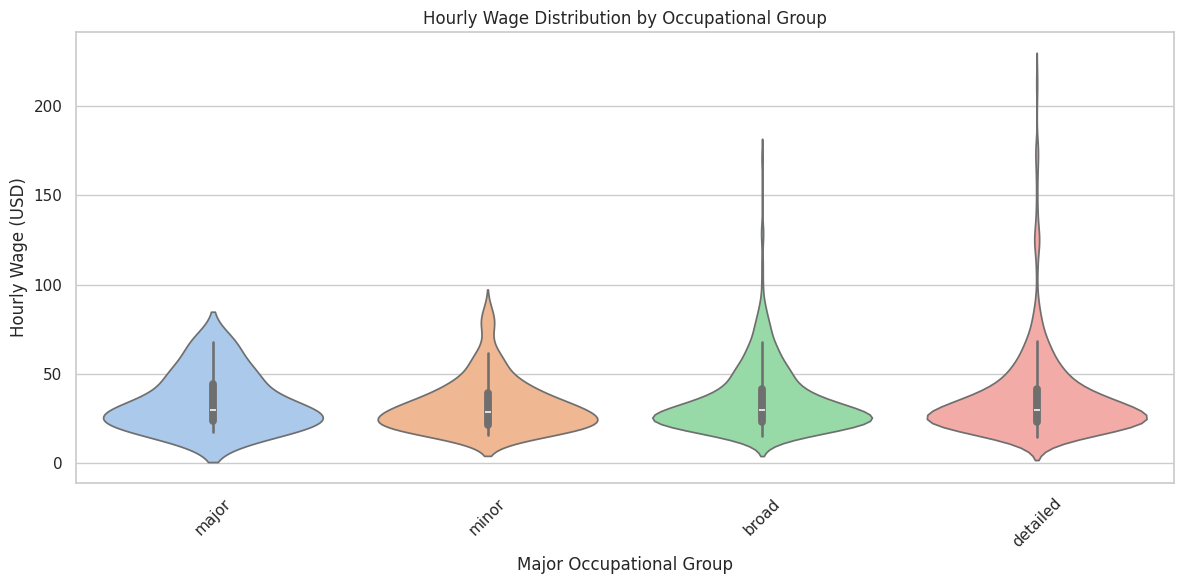

In [32]:
plt.figure(figsize=(12,6))
sns.violinplot(x="soc_group", y="hourly_mean", data=df, palette="pastel")
plt.title("Hourly Wage Distribution by Occupational Group")
plt.xlabel("Major Occupational Group")
plt.ylabel("Hourly Wage (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Correlation Heatmap




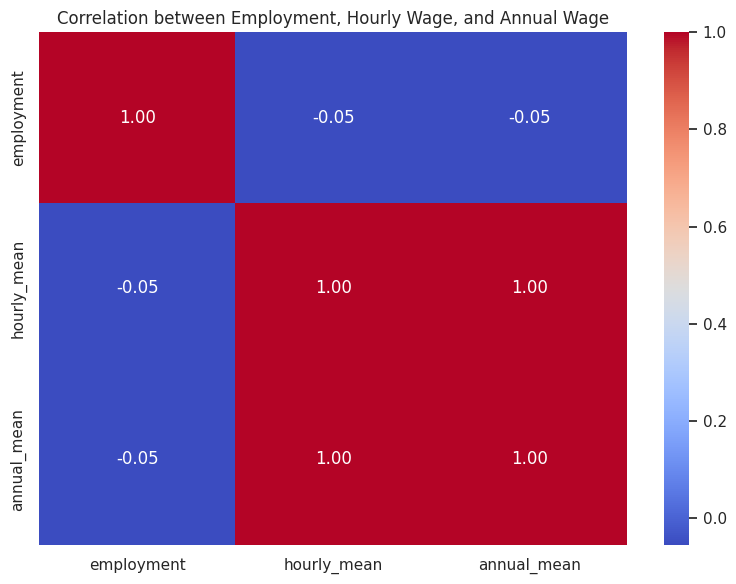

In [33]:
corr = df[["employment","hourly_mean","annual_mean"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Employment, Hourly Wage, and Annual Wage")
plt.tight_layout()
plt.show()

Bubble Plot — Employment vs Annual Wage (size = employment)

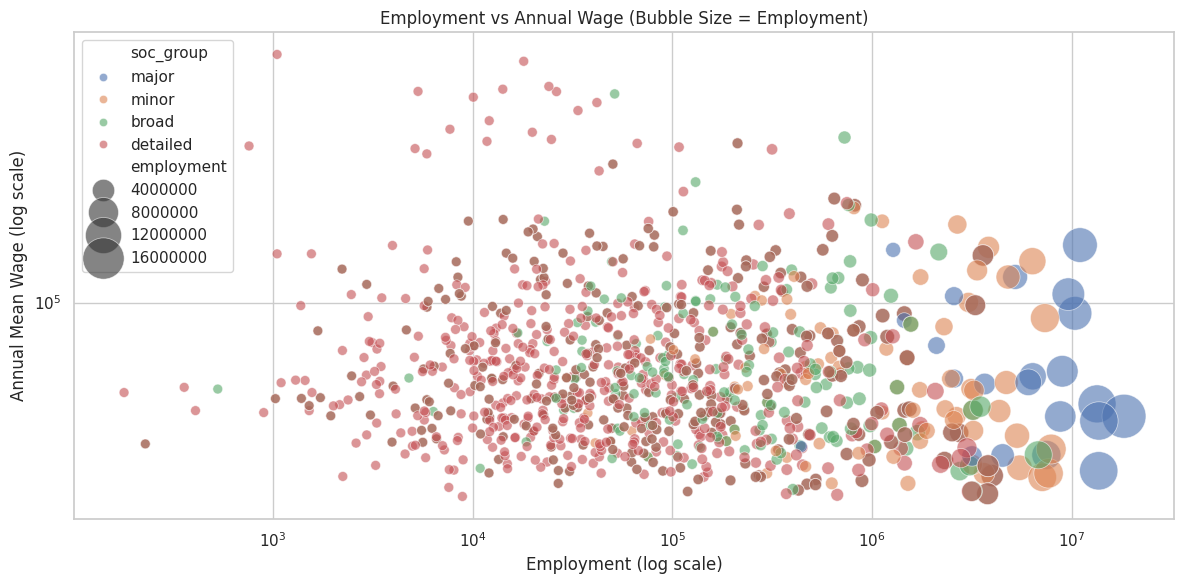

In [34]:
plt.figure(figsize=(12,6))
sns.scatterplot(x="employment", y="annual_mean", size="employment", hue="soc_group",
                data=df, alpha=0.6, sizes=(50,1000))
plt.xscale("log")
plt.yscale("log")
plt.title("Employment vs Annual Wage (Bubble Size = Employment)")
plt.xlabel("Employment (log scale)")
plt.ylabel("Annual Mean Wage (log scale)")
plt.tight_layout()
plt.show()